In [1]:
import os
import nltk
import math
import random
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import NMF
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import polynomial_kernel, rbf_kernel, linear_kernel, pairwise_kernels

In [2]:
# Import the functions module
from functions import *

# Convergence Plots across topics

## Use functions.py

In [3]:
def testing_kernel(X, y, num_topics, ker, lam, max_iter, random_state):
    '''
    Sample function for using all algorithms in functions.py

    Parameters:
    X: data matrix of shape (num_samples, num_features)
    y: 1d array of labels
    num_topics: number of topics for NMF
    ker: kernel for Kernel SSNMF
    lam: lambda for Kernel SSNMF and SSNMF
    max_iter: max iterations for Kernel SSNMF, Convex NMF, and SSNMF

    Returns: list of test accuracies of kernel SSNMF, convex NMF, and SSNMF
    '''
    # Define train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

    # Semi NMF initialization
    F, G = semiNMF(X_train, num_topics, max_iter)

    # Kernel SSNMF
    print('\nKernel SSNMF:', ker)
    G_train, W,residuals = KernelSSNMF(X_train, y_train, lam, G.T, max_iter, ker)
    K = kernel(X_train, ker)
    G_test = (G_train.T @ np.linalg.pinv(K) @ kernel(X=X_train, Y=X_test, kernel_type=ker)).T
    #np.linalg.pinv(W)
    print('Grid search:')
    grid_search = grid_search_svm(G_train, y_train, G_test, y_test)
    print('Best model:')
    kernel_acc = best_svm(grid_search, G_train, G_test, y_train, y_test)

    return kernel_acc

In [4]:
def testing_convex(X, y, num_topics, lam, max_iter, random_state):
    # Define train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

    # Semi NMF initialization
    F, G = semiNMF(X_train, num_topics, max_iter)

    # Convex NMF
    print('\nConvex NMF:')
    G_train, W = ConvexNMF(X_train, G.T, max_iter)
    XTX = X_train.T @ X_train
    G_test = (G_train.T @ np.linalg.inv(X_train @ X_train.T) @ X_train @ X_test.T).T
    #(np.linalg.pinv(W) @ X_train @ np.linalg.inv(XTX) @ X_test.T).T
    print('Grid search:')
    grid_search = grid_search_svm(G_train, y_train, G_test, y_test)
    print('Best model:')
    convex_acc = best_svm(grid_search, G_train, G_test, y_train, y_test)

    return convex_acc

In [5]:
def testing_ssnmf(X, y, num_topics, lam, max_iter, random_state):
    # SSNMF
    print('\nSSNMF:')
    Y_one_hot = np.zeros((y.size, y.max() + 1))
    Y_one_hot[np.arange(y.size), y] = 1
    Y = Y_one_hot
    X_nn = X - np.min(X)
    X_nn_train, X_nn_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)
    X_nn_train, X_nn_test, Y_train, Y_test = train_test_split(X_nn, Y, test_size=0.2, random_state=random_state)

    A, S, B, E = SSNMF(X_nn_train, Y_train, num_topics, lam, max_iter)
    S_train = (np.linalg.pinv(A) @ X_train.T).T
    S_test = (np.linalg.pinv(A) @ X_test.T).T
    print('Grid search:')
    grid_search = grid_search_svm(S_train, y_train, S_test, y_test)
    print('Best model:')
    ssnmf_acc = best_svm(grid_search, S_train, S_test, y_train, y_test)

    return ssnmf_acc

## Load the Embeddings

### Evidence summaries

In [19]:
import csv
import ast
import numpy as np
import pandas as pd

# Define the path to your CSV file in Google Drive
evidence_csv_file = 'embeddings (old ver)/matrixEvidence_df.csv'

evidence_data = []
with open(evidence_csv_file, newline='') as file:
    reader = csv.reader(file)
    #next(reader)  # Skip the first row
    for row in reader:
        # Parse the first column as a list and convert to a NumPy array
        array_list = ast.literal_eval(row[0])
        array_np = np.array(array_list)
        # Append the NumPy array to the list
        evidence_data.append(array_np)

# Stack the arrays together into a single NumPy array
evidence_array = np.vstack(evidence_data)
print(evidence_array)

# Convert the stacked array to a DataFrame
evidence_df = pd.DataFrame(evidence_array)

[[-0.00075468 -0.00769566  0.0082439  ... -0.00138921 -0.02569282
  -0.01049101]
 [ 0.01109792  0.01746758  0.00228139 ... -0.00695056 -0.03161186
  -0.00110861]
 [-0.00154541  0.01209453  0.01028035 ... -0.00802942 -0.03163392
  -0.01421779]
 ...
 [-0.00218866 -0.01813601 -0.0051941  ...  0.00790117 -0.02121647
  -0.01147503]
 [ 0.00633316  0.01042634 -0.02630129 ... -0.01170441 -0.02624748
  -0.0101371 ]
 [ 0.00208848  0.01598962  0.0165723  ... -0.00084564 -0.02288684
  -0.00304718]]


### Testimony summaries

In [20]:
# Define the path to your CSV file in Google Drive
testimony_csv_file = 'embeddings (old ver)/matrixTestimony_df.csv'

testimony_data = []
with open(testimony_csv_file, newline='') as file:
    reader = csv.reader(file)
    #next(reader)  # Skip the first row
    for row in reader:
        # Parse the first column as a list and convert to a NumPy array
        array_list = ast.literal_eval(row[0])
        array_np = np.array(array_list)
        # Append the NumPy array to the list
        testimony_data.append(array_np)

# Stack the arrays together into a single NumPy array
testimony_array = np.vstack(testimony_data)
print(testimony_array)

# Convert the stacked array to a DataFrame
testimony_df = pd.DataFrame(testimony_array)

[[ 0.00293904  0.00032978  0.00839083 ... -0.01245111 -0.01379596
  -0.02044942]
 [-0.00055695  0.01005765  0.00517865 ...  0.00169365 -0.00798619
  -0.02148325]
 [-0.00084438  0.00579875  0.01305926 ... -0.00750199 -0.01064446
  -0.03062615]
 ...
 [ 0.00707643 -0.00078792  0.02325021 ... -0.0006588  -0.01508954
  -0.0172067 ]
 [-0.00069776  0.00957488  0.01053629 ... -0.00646173 -0.00154022
  -0.02587309]
 [-0.00010378  0.01158003  0.01929151 ... -0.00794206 -0.00802532
  -0.02468442]]


### Outcome summaries

In [21]:
# Define the path to your CSV file in Google Drive
outcome_csv_file = 'embeddings (old ver)/matrixGPTExon_df.csv'

outcome_data = []
with open(outcome_csv_file, newline='') as file:
    reader = csv.reader(file)
    #next(reader)  # Skip the first row
    for row in reader:
        # Parse the first column as a list and convert to a NumPy array
        array_list = ast.literal_eval(row[0])
        array_np = np.array(array_list)
        # Append the NumPy array to the list
        outcome_data.append(array_np)

# Stack the arrays together into a single NumPy array
outcome_array = np.vstack(outcome_data)
print(outcome_array)

# Convert the stacked array to a DataFrame
outcome_df = pd.DataFrame(outcome_array)

[[ 0.01298547 -0.00734364  0.00676423 ...  0.00138149 -0.0243552
  -0.00978049]
 [ 0.00692744  0.01198493  0.00155967 ... -0.00592592 -0.02653854
   0.00579283]
 [-0.00141645  0.00702652  0.01082097 ... -0.01004527 -0.01634135
  -0.01351005]
 ...
 [ 0.00953118 -0.00650153  0.01341889 ...  0.00021782 -0.02848792
  -0.00516822]
 [ 0.01994029  0.01098737 -0.01572319 ... -0.01560193 -0.03150027
   0.00422047]
 [-0.00014342  0.02013288  0.02253601 ...  0.0022496  -0.01738263
  -0.01249627]]


In [22]:
# Define the number of rows
total_num = 140
half_num = total_num // 2

# Create the first half of the matrix with [1, 0], the second half of the matrix with [0, 1]
# Concatenate to form the final label matrix Y
Y = np.vstack((np.tile([1, 0], (half_num, 1)), np.tile([0, 1], (total_num - half_num, 1)))) # shape nxk, k classes (k=2)
y = Y[:, 1] # 1 for exo, 0 for non-exo

## Convex NMF  Boxplots

## Evidence

In [23]:
# Parameters
X=evidence_df.values
y=y
num_of_topics = [10, 15, 20, 25]  # List of topics to iterate over
lam = 1
max_iter = 100  # Set a value for max_iter

convex_acc_dict_evidence = {}  # Dictionary to store accuracy lists for each num_of_topic

# Loop over different numbers of topics
for num_topic in num_of_topics:
    convex_acc_ls = []

    for i in range(40):
        # Perform SSNMF-based classification
        convex_acc = testing_convex(X, y, num_topic, lam, max_iter, random_state=i)
        # Store the accuracy for the current random state
        convex_acc_ls.append(convex_acc)
        print(f'num_of_topic={num_topic}, random_state={i}, accuracy={convex_acc}')

    # Store the accuracy list for the current num_of_topic
    convex_acc_dict_evidence[num_topic] = convex_acc_ls


Convex NMF:
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'linear'}
Best Cross-Validation Score: 0.5980237154150198
Test Accuracy: 0.7142857142857143
Best model:
Train Accuracy: 0.6428571428571429
Test Accuracy: 0.7142857142857143
num_of_topic=10, random_state=0, accuracy=0.7142857142857143

Convex NMF:
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.5529644268774703
Test Accuracy: 0.5714285714285714
Best model:
Train Accuracy: 0.6071428571428571
Test Accuracy: 0.5714285714285714
num_of_topic=10, random_state=1, accuracy=0.5714285714285714

Convex NMF:
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'linear'}
Best Cross-Validation Score: 0.6158102766798418
Test Accuracy: 0.6428571428571429
Best model:
Train Accuracy: 0.6607142857142857
Test Accuracy: 0.6428571428571429
num_of_topic=10, random_state=2, accuracy=0.6428571428571429

Convex NMF:
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'ke

/Users/xiangdilin/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/xiangdilin/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/xiangdilin/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu


Convex NMF:
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'linear'}
Best Cross-Validation Score: 0.5893280632411066
Test Accuracy: 0.5714285714285714
Best model:
Train Accuracy: 0.6875
Test Accuracy: 0.5714285714285714
num_of_topic=15, random_state=12, accuracy=0.5714285714285714

Convex NMF:
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'linear'}
Best Cross-Validation Score: 0.6632411067193675
Test Accuracy: 0.6785714285714286
Best model:
Train Accuracy: 0.75
Test Accuracy: 0.6785714285714286
num_of_topic=15, random_state=13, accuracy=0.6785714285714286

Convex NMF:
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'linear'}
Best Cross-Validation Score: 0.6434782608695652
Test Accuracy: 0.6071428571428571
Best model:
Train Accuracy: 0.6785714285714286
Test Accuracy: 0.6071428571428571
num_of_topic=15, random_state=14, accuracy=0.6071428571428571

Convex NMF:
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'rbf'}
Best C

/Users/xiangdilin/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/xiangdilin/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/xiangdilin/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu


Convex NMF:
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.6707509881422924
Test Accuracy: 0.6071428571428571
Best model:
Train Accuracy: 0.7053571428571429
Test Accuracy: 0.6071428571428571
num_of_topic=15, random_state=30, accuracy=0.6071428571428571

Convex NMF:
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.6150197628458498
Test Accuracy: 0.6071428571428571
Best model:
Train Accuracy: 0.7053571428571429
Test Accuracy: 0.6071428571428571
num_of_topic=15, random_state=31, accuracy=0.6071428571428571

Convex NMF:
Grid search:
Best Parameters: {'C': 100, 'gamma': 1, 'kernel': 'linear'}
Best Cross-Validation Score: 0.6252964426877471
Test Accuracy: 0.6071428571428571
Best model:
Train Accuracy: 0.6517857142857143
Test Accuracy: 0.6071428571428571
num_of_topic=15, random_state=32, accuracy=0.6071428571428571

Convex NMF:
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'ker

...


Convex NMF:
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.5359683794466403
Test Accuracy: 0.5357142857142857
Best model:
Train Accuracy: 0.7053571428571429
Test Accuracy: 0.5357142857142857
num_of_topic=20, random_state=8, accuracy=0.5357142857142857

Convex NMF:
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'linear'}
Best Cross-Validation Score: 0.7047430830039525
Test Accuracy: 0.5357142857142857
Best model:
Train Accuracy: 0.75
Test Accuracy: 0.5357142857142857
num_of_topic=20, random_state=9, accuracy=0.5357142857142857

Convex NMF:
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.6347826086956522
Test Accuracy: 0.6428571428571429
Best model:
Train Accuracy: 0.7410714285714286
Test Accuracy: 0.6428571428571429
num_of_topic=20, random_state=10, accuracy=0.6428571428571429

Convex NMF:
Grid search:
Best Parameters: {'C': 0.1, 'gamma': 1, 'kernel': 'rbf'}
Bes

/Users/xiangdilin/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/xiangdilin/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/xiangdilin/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu


Convex NMF:
Grid search:
Best Parameters: {'C': 100, 'gamma': 1, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.5984189723320157
Test Accuracy: 0.5
Best model:
Train Accuracy: 0.6696428571428571
Test Accuracy: 0.5
num_of_topic=20, random_state=12, accuracy=0.5

Convex NMF:
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'linear'}
Best Cross-Validation Score: 0.6173913043478261
Test Accuracy: 0.6428571428571429
Best model:
Train Accuracy: 0.75
Test Accuracy: 0.6428571428571429
num_of_topic=20, random_state=13, accuracy=0.6428571428571429

Convex NMF:
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.6525691699604742
Test Accuracy: 0.6071428571428571
Best model:
Train Accuracy: 0.7321428571428571
Test Accuracy: 0.6071428571428571
num_of_topic=20, random_state=14, accuracy=0.6071428571428571

Convex NMF:
Grid search:
Best Parameters: {'C': 0.1, 'gamma': 1, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.5367588932806324

/Users/xiangdilin/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/xiangdilin/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/xiangdilin/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu


Convex NMF:
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'linear'}
Best Cross-Validation Score: 0.6616600790513834
Test Accuracy: 0.6071428571428571
Best model:
Train Accuracy: 0.75
Test Accuracy: 0.6071428571428571
num_of_topic=25, random_state=24, accuracy=0.6071428571428571

Convex NMF:
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'linear'}
Best Cross-Validation Score: 0.633201581027668
Test Accuracy: 0.6428571428571429
Best model:
Train Accuracy: 0.75
Test Accuracy: 0.6428571428571429
num_of_topic=25, random_state=25, accuracy=0.6428571428571429

Convex NMF:
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'linear'}
Best Cross-Validation Score: 0.5252964426877471
Test Accuracy: 0.6785714285714286
Best model:
Train Accuracy: 0.7142857142857143
Test Accuracy: 0.6785714285714286
num_of_topic=25, random_state=26, accuracy=0.6785714285714286

Convex NMF:
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'linear'}
Best C

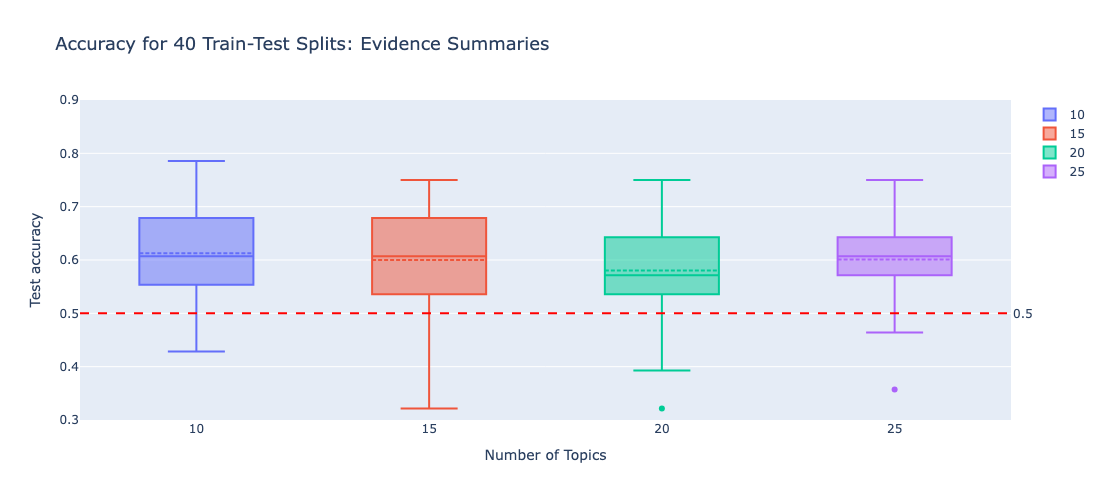

In [25]:
import plotly.graph_objects as go

# Assuming ssnmf_acc_dict is already filled with accuracies from the loops
# Keys in ssnmf_acc_dict are the number of topics, and values are the lists of accuracies

# Extract lists of accuracies from the dictionary
accuracy_lists = [convex_acc_dict_evidence[num_topic] for num_topic in num_of_topics]

# Create a box plot using Plotly
fig = go.Figure()

# Add box plots for each number of topics
for i, num_topic in enumerate(num_of_topics):
    fig.add_trace(go.Box(
        y=accuracy_lists[i],
        name=str(num_topic),
        boxmean=True  # Include the mean in the box plot
    ))

# Add horizontal lines at specific accuracy thresholds
fig.add_hline(y=0.5, line_dash="dash", line_color="red", annotation_text="0.5", annotation_position="right")

# Setting title and labels
fig.update_layout(
    title={
        'text': "Accuracy for 40 Train-Test Splits: Evidence Summaries",
        'font': {
            'size': 18  # Set the desired font size here
        }
    },
    xaxis_title="Number of Topics",
    yaxis_title="Test accuracy",
    xaxis=dict(
        tickvals=list(range(len(num_of_topics))),
        ticktext=[str(topic) for topic in num_of_topics]
    ),
    yaxis=dict(range=[0.3, 0.9]),  # Set y-axis range to [0, 1] for better visualization
    height = 500,
    width = 600
)

# Show plot
fig.show()

## Testimony

In [26]:
# Parameters
X=testimony_df.values
y=y
num_of_topics = [10, 15, 20, 25]  # List of topics to iterate over
lam = 1
max_iter = 100  # Set a value for max_iter

convex_acc_dict_testimony = {}  # Dictionary to store accuracy lists for each num_of_topic

# Loop over different numbers of topics
for num_topic in num_of_topics:
    convex_acc_ls = []

    for i in range(40):
        # Perform SSNMF-based classification
        convex_acc = testing_convex(X, y, num_topic, lam, max_iter, random_state=i)
        # Store the accuracy for the current random state
        convex_acc_ls.append(convex_acc)
        print(f'num_of_topic={num_topic}, random_state={i}, accuracy={convex_acc}')

    # Store the accuracy list for the current num_of_topic
    convex_acc_dict_testimony[num_topic] = convex_acc_ls


Convex NMF:
Grid search:
Best Parameters: {'C': 100, 'gamma': 1, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.5980237154150198
Test Accuracy: 0.4642857142857143
Best model:
Train Accuracy: 0.6339285714285714
Test Accuracy: 0.4642857142857143
num_of_topic=10, random_state=0, accuracy=0.4642857142857143

Convex NMF:
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.5715415019762846
Test Accuracy: 0.39285714285714285
Best model:
Train Accuracy: 0.6071428571428571
Test Accuracy: 0.39285714285714285
num_of_topic=10, random_state=1, accuracy=0.39285714285714285

Convex NMF:
Grid search:
Best Parameters: {'C': 0.1, 'gamma': 0.001, 'kernel': 'poly'}
Best Cross-Validation Score: 0.5276679841897234
Test Accuracy: 0.6071428571428571
Best model:
Train Accuracy: 0.5714285714285714
Test Accuracy: 0.6071428571428571
num_of_topic=10, random_state=2, accuracy=0.6071428571428571

Convex NMF:
Grid search:
Best Parameters: {'C': 0.1, 'gamma': 1, 'ker

/Users/xiangdilin/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/xiangdilin/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/xiangdilin/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.




Convex NMF:
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.6079051383399209
Test Accuracy: 0.35714285714285715
Best model:
Train Accuracy: 0.6160714285714286
Test Accuracy: 0.35714285714285715
num_of_topic=10, random_state=4, accuracy=0.35714285714285715

Convex NMF:
Grid search:
Best Parameters: {'C': 0.1, 'gamma': 1, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.5086956521739131
Test Accuracy: 0.4642857142857143
Best model:
Train Accuracy: 0.5089285714285714
Test Accuracy: 0.4642857142857143
num_of_topic=10, random_state=5, accuracy=0.4642857142857143


/Users/xiangdilin/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/xiangdilin/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/xiangdilin/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.




Convex NMF:
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'linear'}
Best Cross-Validation Score: 0.5355731225296443
Test Accuracy: 0.5
Best model:
Train Accuracy: 0.5803571428571429
Test Accuracy: 0.5
num_of_topic=10, random_state=6, accuracy=0.5

Convex NMF:
Grid search:
Best Parameters: {'C': 0.1, 'gamma': 1, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.5268774703557313
Test Accuracy: 0.39285714285714285
Best model:
Train Accuracy: 0.5267857142857143
Test Accuracy: 0.39285714285714285
num_of_topic=10, random_state=7, accuracy=0.39285714285714285


...

/Users/xiangdilin/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/xiangdilin/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/xiangdilin/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.




Convex NMF:
Grid search:
Best Parameters: {'C': 0.1, 'gamma': 1, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.5086956521739131
Test Accuracy: 0.4642857142857143
Best model:
Train Accuracy: 0.5089285714285714
Test Accuracy: 0.4642857142857143
num_of_topic=25, random_state=38, accuracy=0.4642857142857143


/Users/xiangdilin/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/xiangdilin/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/xiangdilin/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.




Convex NMF:
Grid search:
Best Parameters: {'C': 0.1, 'gamma': 1, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.5086956521739131
Test Accuracy: 0.4642857142857143
Best model:
Train Accuracy: 0.5089285714285714
Test Accuracy: 0.4642857142857143
num_of_topic=25, random_state=39, accuracy=0.4642857142857143


/Users/xiangdilin/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/xiangdilin/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/xiangdilin/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



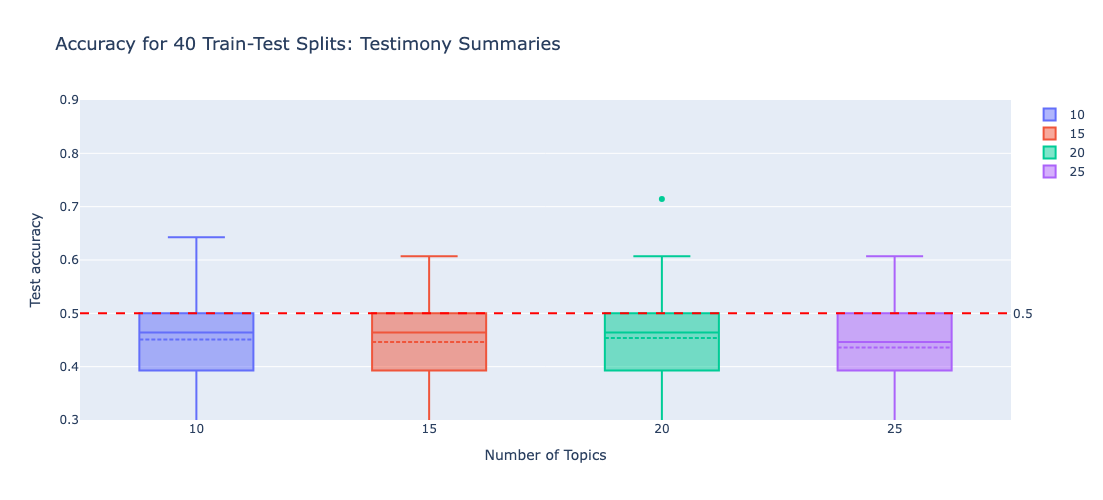

In [27]:
import plotly.graph_objects as go

# Assuming ssnmf_acc_dict is already filled with accuracies from the loops
# Keys in ssnmf_acc_dict are the number of topics, and values are the lists of accuracies

# Extract lists of accuracies from the dictionary
accuracy_lists = [convex_acc_dict_testimony[num_topic] for num_topic in num_of_topics]

# Create a box plot using Plotly
fig = go.Figure()

# Add box plots for each number of topics
for i, num_topic in enumerate(num_of_topics):
    fig.add_trace(go.Box(
        y=accuracy_lists[i],
        name=str(num_topic),
        boxmean=True  # Include the mean in the box plot
    ))

# Add horizontal lines at specific accuracy thresholds
fig.add_hline(y=0.5, line_dash="dash", line_color="red", annotation_text="0.5", annotation_position="right")

# Setting title and labels
fig.update_layout(
    title={
        'text': "Accuracy for 40 Train-Test Splits: Testimony Summaries",
        'font': {
            'size': 18  # Set the desired font size here
        }
    },
    xaxis_title="Number of Topics",
    yaxis_title="Test accuracy",
    xaxis=dict(
        tickvals=list(range(len(num_of_topics))),
        ticktext=[str(topic) for topic in num_of_topics]
    ),
    yaxis=dict(range=[0.3, 0.9]),  # Set y-axis range to [0, 1] for better visualization
    height = 500,
    width = 600
)

# Show plot
fig.show()

## Outcome

In [28]:
# Parameters
X=outcome_df.values
y=y
num_of_topics = [10, 15, 20, 25]  # List of topics to iterate over
lam = 1
max_iter = 100  # Set a value for max_iter

convex_acc_dict = {}  # Dictionary to store accuracy lists for each num_of_topic

# Loop over different numbers of topics
for num_topic in num_of_topics:
    convex_acc_ls = []

    for i in range(40):
        # Perform SSNMF-based classification
        convex_acc = testing_convex(X, y, num_topic, lam, max_iter, random_state=i)
        # Store the accuracy for the current random state
        convex_acc_ls.append(convex_acc)
        print(f'num_of_topic={num_topic}, random_state={i}, accuracy={convex_acc}')

    # Store the accuracy list for the current num_of_topic
    convex_acc_dict[num_topic] = convex_acc_ls


Convex NMF:
Grid search:
Best Parameters: {'C': 100, 'gamma': 1, 'kernel': 'linear'}
Best Cross-Validation Score: 0.5885375494071147
Test Accuracy: 0.75
Best model:
Train Accuracy: 0.6517857142857143
Test Accuracy: 0.75
num_of_topic=10, random_state=0, accuracy=0.75

Convex NMF:
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'linear'}
Best Cross-Validation Score: 0.633596837944664
Test Accuracy: 0.7857142857142857
Best model:
Train Accuracy: 0.6785714285714286
Test Accuracy: 0.7857142857142857
num_of_topic=10, random_state=1, accuracy=0.7857142857142857

Convex NMF:
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'linear'}
Best Cross-Validation Score: 0.6533596837944664
Test Accuracy: 0.7142857142857143
Best model:
Train Accuracy: 0.7053571428571429
Test Accuracy: 0.7142857142857143
num_of_topic=10, random_state=2, accuracy=0.7142857142857143

Convex NMF:
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'rbf'}
Best Cross-Validation Score

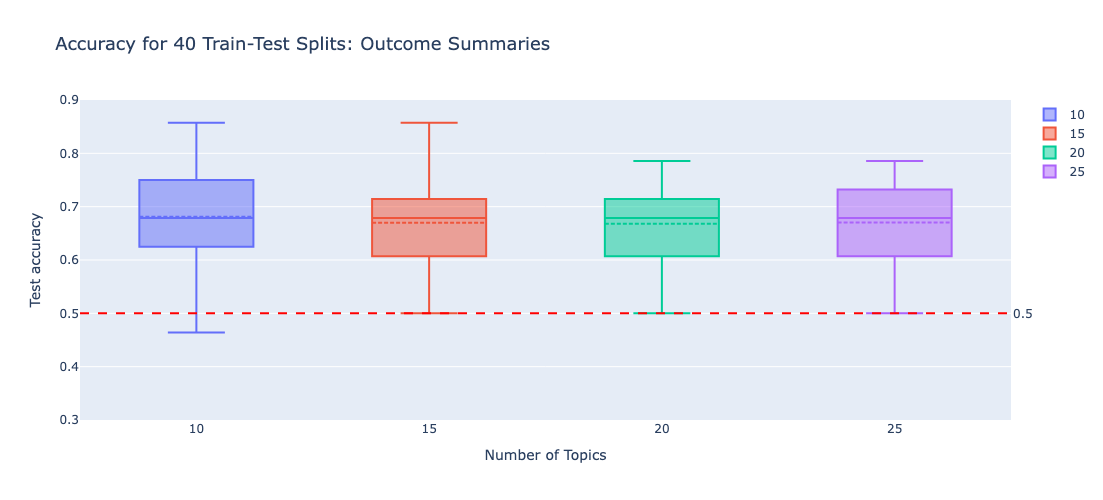

In [34]:
import plotly.graph_objects as go

# Assuming ssnmf_acc_dict is already filled with accuracies from the loops
# Keys in ssnmf_acc_dict are the number of topics, and values are the lists of accuracies

# Extract lists of accuracies from the dictionary
accuracy_lists = [convex_acc_dict[num_topic] for num_topic in num_of_topics]

# Create a box plot using Plotly
fig = go.Figure()

# Add box plots for each number of topics
for i, num_topic in enumerate(num_of_topics):
    fig.add_trace(go.Box(
        y=accuracy_lists[i],
        name=str(num_topic),
        boxmean=True  # Include the mean in the box plot
    ))

# Add horizontal lines at specific accuracy thresholds
fig.add_hline(y=0.5, line_dash="dash", line_color="red", annotation_text="0.5", annotation_position="right")

# Setting title and labels
fig.update_layout(
    title={
        'text': "Accuracy for 40 Train-Test Splits: Outcome Summaries",
        'font': {
            'size': 18  # Set the desired font size here
        }
    },
    xaxis_title="Number of Topics",
    yaxis_title="Test accuracy",
    xaxis=dict(
        tickvals=list(range(len(num_of_topics))),
        ticktext=[str(topic) for topic in num_of_topics]
    ),
    yaxis=dict(range=[0.3, 0.9]),  # Set y-axis range to [0, 1] for better visualization
    height = 500,
    width = 600
)

# Show plot
fig.show()

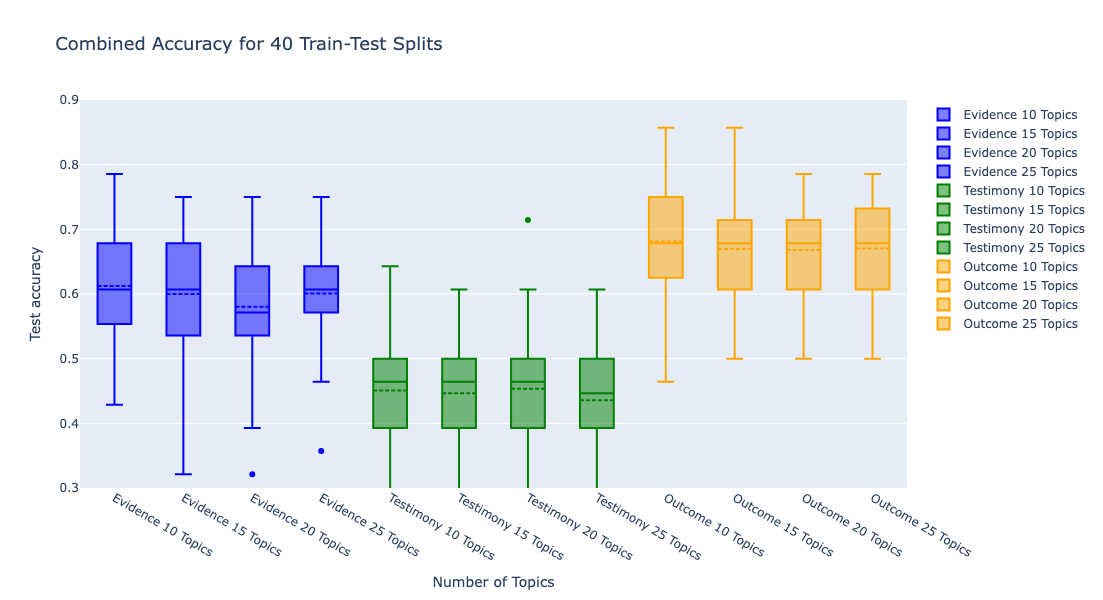

In [32]:
import plotly.graph_objects as go

# Colors for each category
colors = {
    "Evidence Summaries": "blue",
    "Testimony Summaries": "green",
    "Outcome Summaries": "orange"
}

# Create a combined plot
fig = go.Figure()

# Evidence Summaries
accuracy_lists_evidence = [convex_acc_dict_evidence[num_topic] for num_topic in num_of_topics]
for i, num_topic in enumerate(num_of_topics):
    fig.add_trace(go.Box(
        y=accuracy_lists_evidence[i],
        name=f"Evidence {num_topic} Topics",
        marker_color=colors["Evidence Summaries"],
        boxmean=True
    ))

# Testimony Summaries
accuracy_lists_testimony = [convex_acc_dict_testimony[num_topic] for num_topic in num_of_topics]
for i, num_topic in enumerate(num_of_topics):
    fig.add_trace(go.Box(
        y=accuracy_lists_testimony[i],
        name=f"Testimony {num_topic} Topics",
        marker_color=colors["Testimony Summaries"],
        boxmean=True
    ))

# Outcome Summaries
accuracy_lists_outcome = [convex_acc_dict[num_topic] for num_topic in num_of_topics]
for i, num_topic in enumerate(num_of_topics):
    fig.add_trace(go.Box(
        y=accuracy_lists_outcome[i],
        name=f"Outcome {num_topic} Topics",
        marker_color=colors["Outcome Summaries"],
        boxmean=True
    ))

# Update layout
fig.update_layout(
    title={
        'text': "Combined Accuracy for 40 Train-Test Splits",
        'font': {
            'size': 18
        }
    },
    xaxis_title="Number of Topics",
    yaxis_title="Test accuracy",
    yaxis=dict(range=[0.3, 0.9]),  # Set y-axis range to [0.3, 0.9] for better visualization
    height=600,
    width=1000
)

# Show plot
fig.show()


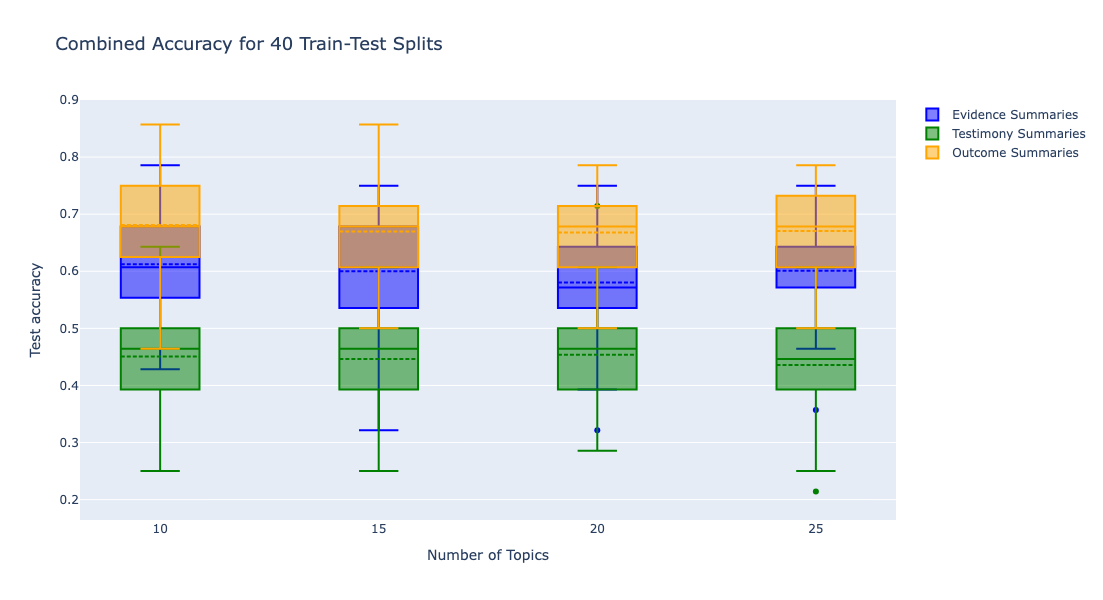

In [33]:
import plotly.graph_objects as go

# Colors for each category
colors = {
    "Evidence Summaries": "blue",
    "Testimony Summaries": "green",
    "Outcome Summaries": "orange"
}

# Create a combined plot
fig = go.Figure()

# Evidence Summaries
accuracy_lists_evidence = [convex_acc_dict_evidence[num_topic] for num_topic in num_of_topics]
for i, num_topic in enumerate(num_of_topics):
    fig.add_trace(go.Box(
        y=accuracy_lists_evidence[i],
        x=[num_topic] * len(accuracy_lists_evidence[i]),  # Set x-axis as number of topics
        name="Evidence Summaries" if i == 0 else "",  # Show legend only for the first occurrence
        marker_color=colors["Evidence Summaries"],
        boxmean=True,
        width=1.8,  # Increase the width of the boxes
        showlegend=i == 0  # Show legend only for the first occurrence
    ))

# Testimony Summaries
accuracy_lists_testimony = [convex_acc_dict_testimony[num_topic] for num_topic in num_of_topics]
for i, num_topic in enumerate(num_of_topics):
    fig.add_trace(go.Box(
        y=accuracy_lists_testimony[i],
        x=[num_topic] * len(accuracy_lists_testimony[i]),  # Set x-axis as number of topics
        name="Testimony Summaries" if i == 0 else "",  # Show legend only for the first occurrence
        marker_color=colors["Testimony Summaries"],
        boxmean=True,
        width=1.8,  # Increase the width of the boxes
        showlegend=i == 0  # Show legend only for the first occurrence
    ))

# Outcome Summaries
accuracy_lists_outcome = [convex_acc_dict[num_topic] for num_topic in num_of_topics]
for i, num_topic in enumerate(num_of_topics):
    fig.add_trace(go.Box(
        y=accuracy_lists_outcome[i],
        x=[num_topic] * len(accuracy_lists_outcome[i]),  # Set x-axis as number of topics
        name="Outcome Summaries" if i == 0 else "",  # Show legend only for the first occurrence
        marker_color=colors["Outcome Summaries"],
        boxmean=True,
        width=1.8,  # Increase the width of the boxes
        showlegend=i == 0  # Show legend only for the first occurrence
    ))

# Find the minimum value across all data points
all_data = accuracy_lists_evidence + accuracy_lists_testimony + accuracy_lists_outcome
min_value = min([min(data) for data in all_data])

# Update layout
fig.update_layout(
    title={
        'text': "Combined Accuracy for 40 Train-Test Splits",
        'font': {
            'size': 18
        }
    },
    xaxis_title="Number of Topics",
    yaxis_title="Test accuracy",
    yaxis=dict(range=[min_value - 0.05, 0.9]),  # Set y-axis minimum a bit lower than actual minimum
    height=600,
    width=800,
    boxmode='group',  # Group the boxes together
    boxgroupgap=0.3,  # Increase spacing between groups of boxes
    boxgap=0.5  # Increase spacing within each group of boxes
)

# Show plot
fig.show()
